# Building Damage Assessment — Siamese Change-Detection on xBD

This notebook trains a dual-branch Siamese network for building localization and 4-class damage classification on the xBD dataset. Designed for **Lightning AI Studio** with a single NVIDIA L4 GPU (24 GB VRAM).

## Sections
1. Environment Setup
2. Hyperparameters
3. Checkpoint Resume
4. Dataset Acquisition
5. Preprocessing & DataLoader
6. Model Definition
7. Loss Functions
8. Training Loop
9. Evaluation
10. Export Function
11. Generate Demo Sites
12. OPTIONAL — Ordinal Loss
13. CPU Dry Run
14-18. OPTIONAL — Maxar OOD Demo Sites

---
## Cell 1 — Environment Setup
Pin exact versions for reproducibility. CUDA 12.4 wheels for the L4 GPU.

In [1]:
import subprocess, sys

def pip_install(*packages, index_url=None):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--prefer-binary"]
    if index_url:
        cmd += ["--index-url", index_url]
    cmd += list(packages)
    subprocess.check_call(cmd)

print("Starting consolidated installation...")

# Install everything in two main passes to handle custom index for Torch
pip_install(
    "torch==2.5.0", "torchvision",
    index_url="https://download.pytorch.org/whl/cu124"
)

pip_install(
    "segmentation-models-pytorch==0.5.0",
    "albumentations>=1.4.0,<2.0",
    "opencv-python-headless>=4.9",
    "rasterio>=1.3,<1.5",
    "geopandas>=0.14,<2.0",
    "shapely>=2.0,<3.0",
    "datasets>=2.19,<4.0",
    "huggingface_hub>=0.23,<1.0",
    "matplotlib>=3.8",
    "scikit-learn>=1.4",
    "scipy>=1.11",
    "tqdm",
    "pystac-client>=0.7",
    "leafmap>=0.35",
    "rio-tiler>=6.0"
)

print("\n✅ All dependencies installed efficiently.")

Starting consolidated installation...

✅ All dependencies installed efficiently.


In [2]:
import torch
import torchvision
import numpy as np

print(f"PyTorch  : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU      : {gpu_name}")
    print(f"VRAM     : {vram_gb:.1f} GB")
    print(f"CUDA ver : {torch.version.cuda}")
    print(f"bf16 supported: {torch.cuda.is_bf16_supported()}")
else:
    print("\n⚠️  NO GPU DETECTED — training will be extremely slow.")
    print("   This notebook is designed for Lightning AI Studio with an L4 GPU.")
    print("   The CPU dry-run cell (Cell 13) will still work.")

PyTorch  : 2.5.0+cu124
Torchvision: 0.20.0+cu124
CUDA available: True
GPU      : NVIDIA L4
VRAM     : 23.7 GB
CUDA ver : 12.4
bf16 supported: True


---
## Cell 2 — Hyperparameters & Configuration
All tunable values in one place. Edit here, not scattered through the code.

In [3]:
import os
from pathlib import Path

# ╔══════════════════════════════════════════════════════════════╗
# ║                    HYPERPARAMETERS                          ║
# ╚══════════════════════════════════════════════════════════════╝

BATCH_SIZE        = 4           # see note below -- measured empirically, not guessed
NUM_EPOCHS        = 15
LEARNING_RATE     = 1e-4
WEIGHT_DECAY      = 1e-5
IMG_SIZE          = 1024        # Native xBD resolution — do not downsample
NUM_WORKERS       = 0           # see note below -- this is deliberate, not a placeholder

# Localization loss weights (BCE + Dice)
LOC_BCE_WEIGHT    = 0.5
LOC_DICE_WEIGHT   = 0.5

# Damage loss
FOCAL_GAMMA       = 2.0         # For optional focal loss
USE_FOCAL_LOSS    = False       # Set True to add focal term

# Checkpointing
CHECKPOINT_EVERY_N_STEPS = 500
EARLY_STOP_PATIENCE      = 3

# Dataset filtering — pick disaster types for a balanced subset
TARGET_DISASTER_PREFIXES = [
    "hurricane",   # wind damage
    "typhoon",     # wind damage (Pacific)
    "earthquake",  # seismic
    "flooding",    # flood
    "flood",       # flood (alternate naming)
    "tsunami",     # seismic + water
    "fire",        # wildfire
]

# ── NUM_WORKERS=0 is deliberate, not a placeholder ──────────────────
# With num_workers>0, PyTorch's DataLoader forks worker processes, and
# every access to a row from the Arrow-backed dataset in XBDDataset
# triggers Python refcounting on shared memory, which triggers
# copy-on-write page duplication. Memory climbs steadily over the
# course of an epoch as workers touch more of the dataset -- this is a
# well-documented PyTorch/HF-datasets interaction (see e.g.
# github.com/pytorch/pytorch/issues/13246), not something specific to
# any one platform or GPU. Confirmed by a real crash: with
# NUM_WORKERS=2 on a 13.6GB-RAM Colab session, this OOM'd right around
# the halfway point of epoch 1. Raising NUM_WORKERS back up (e.g. for
# "more compute on a bigger GPU") makes this WORSE, not better, since
# it has nothing to do with GPU/VRAM -- it's host-side RAM. Data
# loading runs single-process instead; slower per-epoch wall time, but
# it removes this failure mode entirely rather than gambling on having
# enough RAM headroom on whatever machine this runs on next.
#
# BATCH_SIZE=4 is likewise measured, not a round-number guess: the
# real Colab run above used batch_size=2 at 1024x1024 and reported
# 9.6GB VRAM used on a 15.6GB T4. That implies roughly ~4.3GB/sample
# of activation memory at this resolution with this dual-branch model,
# so batch_size=8 (the old default) would need on the order of ~35GB --
# more than even an L4's 24GB. batch_size=4 (~18GB estimated) leaves
# real headroom. This is an estimate, not a guarantee (activation
# memory doesn't always scale perfectly linearly) -- run the first
# training step and check `torch.cuda.max_memory_allocated()` before
# trusting it for a full 15-epoch run; bump up cautiously from there
# if there's VRAM to spare, one step at a time, not back to 8 in one jump.

# Paths — Lightning AI persistent storage
# On Lightning AI Studio: /teamspace/studios/this_studio persists across sessions
# Locally or elsewhere: falls back to ./workspace
_lightning_dir = Path("/teamspace/studios/this_studio")
PERSISTENT_DIR = _lightning_dir if _lightning_dir.exists() else Path("./workspace")
PERSISTENT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR  = PERSISTENT_DIR / "data_cache"
CKPT_DIR   = PERSISTENT_DIR / "checkpoints"
OUTPUT_DIR = PERSISTENT_DIR / "demo_sites"
MODEL_DIR  = PERSISTENT_DIR / "models"

for d in [CACHE_DIR, CKPT_DIR, OUTPUT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Mixed precision dtype
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device      : {DEVICE}")
print(f"AMP dtype   : {AMP_DTYPE}")
print(f"Persistent  : {PERSISTENT_DIR}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : {NUM_EPOCHS}")
print(f"Image size  : {IMG_SIZE}x{IMG_SIZE}")

Device      : cuda
AMP dtype   : torch.bfloat16
Persistent  : /teamspace/studios/this_studio
Batch size  : 4
Epochs      : 15
Image size  : 1024x1024


---
## Cell 3 — Resume from Checkpoint
No-op if no checkpoint exists. Otherwise loads model, optimizer, and scaler state.

In [4]:
def find_latest_checkpoint(ckpt_dir: Path):
    """Find the latest checkpoint file in ckpt_dir."""
    ckpts = sorted(ckpt_dir.glob("checkpoint_*.pt"), key=lambda p: p.stat().st_mtime)
    if ckpts:
        return ckpts[-1]
    return None

def load_checkpoint(ckpt_path, model=None, optimizer=None, scaler=None):
    """Load checkpoint and return metadata dict."""
    print(f"Loading checkpoint: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    if model is not None and "model_state" in ckpt:
        model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scaler is not None and "scaler_state" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt

def save_checkpoint(ckpt_dir, model, optimizer, scaler, epoch, step, best_score, tag=""):
    """Save full training state."""
    fname = f"checkpoint_epoch{epoch:03d}_step{step:06d}{tag}.pt"
    path = ckpt_dir / fname
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": epoch,
        "step": step,
        "best_score": best_score,
    }, path)
    print(f"  💾 Checkpoint saved: {path.name}")
    return path

# Check for existing checkpoint
RESUME_CKPT = find_latest_checkpoint(CKPT_DIR)
START_EPOCH = 0
START_STEP = 0
BEST_SCORE = 0.0

if RESUME_CKPT:
    _ckpt_meta = torch.load(RESUME_CKPT, map_location="cpu", weights_only=False)
    START_EPOCH = _ckpt_meta.get("epoch", 0)
    START_STEP = _ckpt_meta.get("step", 0)
    BEST_SCORE = _ckpt_meta.get("best_score", 0.0)
    print(f"📂 Found checkpoint: {RESUME_CKPT.name}")
    print(f"   Will resume from epoch {START_EPOCH}, step {START_STEP}, best_score {BEST_SCORE:.4f}")
    del _ckpt_meta
else:
    print("No checkpoint found — starting fresh.")

No checkpoint found — starting fresh.


---
## Cell 4 — Dataset Acquisition
Load xBD from the HuggingFace mirror and filter to a manageable subset.

In [5]:
from datasets import load_dataset
from collections import Counter
import re
import shutil
import psutil

# Check system resources upfront
_mem = psutil.virtual_memory()
_disk = shutil.disk_usage(str(CACHE_DIR.parent))
print(f"System RAM : {_mem.available / 1e9:.1f} GB available / {_mem.total / 1e9:.1f} GB total")
print(f"Disk space : {_disk.free / 1e9:.1f} GB free")

def extract_disaster_type(image_name: str) -> str:
    """Extract disaster type from xBD image_name.

    xBD naming convention: {disaster-name}_{tile_id}_{pre|post}_disaster.png
    Examples:
      - hurricane-michael_00000001_pre_disaster.png  -> hurricane-michael
      - socal-fire_00000042_post_disaster.png        -> socal-fire
      - midwest-flooding_00000003_pre_disaster.png   -> midwest-flooding
    """
    match = re.match(r'^(.+?)_\d{5,}', image_name)
    if match:
        return match.group(1).lower()
    return image_name.split('_')[0].lower()

def matches_target_disaster(disaster_name: str, prefixes: list) -> bool:
    """Check if disaster name matches any of our target prefixes."""
    for prefix in prefixes:
        if prefix in disaster_name:
            return True
    return False

# ── Step 1: Load ONLY 'train' split into on-disk Arrow cache ─────────────
# 1. We specify split='train' so HuggingFace ONLY downloads the 17 train
#    parquet files (~8 GB). test/hold/tier3 (~16 GB) are NOT downloaded.
# 2. Crucially, PyArrow memory-maps the tables on disk: images remain
#    compressed on disk until individual batches are requested in Cell 5.
#    System RAM footprint remains minimal (~50-100 MB), avoiding Colab OOM.
print("\nDownloading / loading xBD 'train' split from HuggingFace...")
print("(Downloads ~8 GB to disk cache; images are memory-mapped, NOT loaded into RAM)")

raw_train = load_dataset(
    "hannan022/xview2-xbd",
    split="train",
    cache_dir=str(CACHE_DIR),
    trust_remote_code=True,
)

# ── Step 2: Defensive schema check ──────────────────────────────────────
EXPECTED_COLUMNS = {"t1_image", "t2_image", "t1_mask", "t2_mask", "image_name"}
actual_columns = set(raw_train.column_names)
missing = EXPECTED_COLUMNS - actual_columns
if missing:
    raise ValueError(
        f"Dataset schema mismatch! Expected columns {EXPECTED_COLUMNS}, "
        f"but got {actual_columns}. Missing: {missing}."
    )
print(f"\n✅ Schema check passed — columns: {raw_train.column_names}")

# ── Step 3: Zero-RAM filtering via metadata indexing ───────────────────
# Accessing raw_train['image_name'] reads ONLY the string column from Arrow.
# It does NOT decode or load any images into system memory (< 1 MB RAM).
image_names = raw_train["image_name"]
disaster_types = [extract_disaster_type(name) for name in image_names]
disaster_counts = Counter(disaster_types)

matching_indices = [
    i for i, dtype in enumerate(disaster_types)
    if matches_target_disaster(dtype, TARGET_DISASTER_PREFIXES)
]

print(f"\nScanned {len(image_names)} total rows in 'train' split.")
print(f"Matched {len(matching_indices)} rows for TARGET_DISASTER_PREFIXES.\n")

print("Full disaster type distribution (train split):")
for dtype, count in disaster_counts.most_common():
    marker = " ✅" if matches_target_disaster(dtype, TARGET_DISASTER_PREFIXES) else "  "
    print(f"  {dtype:40s} {count:5d}{marker}")

if len(matching_indices) == 0:
    raise ValueError("No rows matched TARGET_DISASTER_PREFIXES after scanning the 'train' split.")

# ── Step 4: Create memory-mapped filtered view via .select() ───────────
# .select(indices) creates an instant index view over the on-disk Arrow table.
# Uses ZERO additional disk space and ~0 MB RAM!
filtered_ds = {
    "train": raw_train.select(matching_indices)
}
print(f"\n✅ filtered_ds['train'] ready: {len(filtered_ds['train'])} samples "
      f"with columns: {filtered_ds['train'].column_names}")


System RAM : 28.4 GB available / 33.7 GB total
Disk space : 349.3 GB free

(Downloads ~8 GB to disk cache; images are memory-mapped, NOT loaded into RAM)


README.md:   0%|          | 0.00/793 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

data/train-00000-of-00017.parquet:   0%|          | 0.00/509M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/2799 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/933 [00:00<?, ? examples/s]

Generating hold split:   0%|          | 0/933 [00:00<?, ? examples/s]

Generating tier3 split:   0%|          | 0/3378 [00:00<?, ? examples/s]


✅ Schema check passed — columns: ['t1_image', 't2_image', 't1_mask', 't2_mask', 'image_name']

Scanned 2799 total rows in 'train' split.
Matched 2781 rows for TARGET_DISASTER_PREFIXES.

Full disaster type distribution (train split):
  train/images/socal-fire                    823 ✅
  train/images/hurricane-michael             343 ✅
  train/images/hurricane-harvey              319 ✅
  train/images/hurricane-florence            319 ✅
  train/images/midwest-flooding              279 ✅
  train/images/hurricane-matthew             238 ✅
  train/images/santa-rosa-wildfire           226 ✅
  train/images/mexico-earthquake             121 ✅
  train/images/palu-tsunami                  113 ✅
  train/images/guatemala-volcano              18  

✅ filtered_ds['train'] ready: 2781 samples with columns: ['t1_image', 't2_image', 't1_mask', 't2_mask', 'image_name']


In [6]:
# Filtering completed via zero-copy index selection in Cell 4 above.
# filtered_ds['train'] is an on-disk memory-mapped dataset (RAM usage ~0 MB).
print(f"filtered_ds['train'] ready: {len(filtered_ds['train'])} samples.")


filtered_ds['train'] ready: 2781 samples.


---
## Cell 5 — Preprocessing & Dataset Class
Decode images from HF dataset bytes, build PyTorch datasets with augmentation.

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import io
from sklearn.model_selection import StratifiedShuffleSplit


class XBDDataset(Dataset):
    """PyTorch dataset for xBD pre/post image pairs with damage masks.
    
    Expects HuggingFace dataset rows with columns:
      - t1_image: pre-disaster image (PIL Image or bytes)
      - t2_image: post-disaster image (PIL Image or bytes)
      - t1_mask:  building localization mask (binary)
      - t2_mask:  damage classification mask (0=bg, 1=no-damage, 2=minor, 3=major, 4=destroyed)
      - image_name: string identifier
    """
    
    # Damage tiers: pixel value -> class index for CE loss (0-indexed)
    # t2_mask values: 0=background, 1=no-damage, 2=minor, 3=major, 4=destroyed
    # We map: 1->0(no-damage), 2->1(minor), 3->2(major), 4->3(destroyed)
    # Background (0) stays 0 but is masked out during loss computation
    DAMAGE_CLASSES = 4
    TIER_NAMES = ["no-damage", "minor-damage", "major-damage", "destroyed"]
    
    def __init__(self, hf_dataset, transform=None, img_size=1024):
        self.data = hf_dataset
        self.transform = transform
        self.img_size = img_size
    
    def __len__(self):
        return len(self.data)
    
    def _decode_image(self, img_data):
        """Decode image from HF dataset (PIL Image or bytes) to numpy array."""
        if isinstance(img_data, Image.Image):
            img = img_data.convert("RGB")
        elif isinstance(img_data, bytes):
            img = Image.open(io.BytesIO(img_data)).convert("RGB")
        elif isinstance(img_data, dict) and "bytes" in img_data:
            img = Image.open(io.BytesIO(img_data["bytes"])).convert("RGB")
        else:
            raise TypeError(f"Unexpected image type: {type(img_data)}")
        return np.array(img)
    
    def _decode_mask(self, mask_data):
        """Decode mask from HF dataset to numpy array."""
        if isinstance(mask_data, Image.Image):
            mask = mask_data
        elif isinstance(mask_data, bytes):
            mask = Image.open(io.BytesIO(mask_data))
        elif isinstance(mask_data, dict) and "bytes" in mask_data:
            mask = Image.open(io.BytesIO(mask_data["bytes"]))
        else:
            raise TypeError(f"Unexpected mask type: {type(mask_data)}")
        return np.array(mask)
    
    def __getitem__(self, idx):
        row = self.data[idx]
        
        # Decode images
        pre_img = self._decode_image(row["t1_image"])    # (H, W, 3)
        post_img = self._decode_image(row["t2_image"])   # (H, W, 3)
        
        # Decode masks
        loc_mask = self._decode_mask(row["t1_mask"])     # building footprint (binary)
        dmg_mask = self._decode_mask(row["t2_mask"])     # damage classes
        
        # Ensure masks are 2D
        if loc_mask.ndim == 3:
            loc_mask = loc_mask[:, :, 0]
        if dmg_mask.ndim == 3:
            dmg_mask = dmg_mask[:, :, 0]
        
        # Binarize loc_mask (any non-zero -> building)
        loc_mask = (loc_mask > 0).astype(np.uint8)
        
        # Apply augmentations (same transform to all)
        if self.transform:
            transformed = self.transform(
                image=pre_img,
                image_post=post_img,
                mask=loc_mask,
                mask_dmg=dmg_mask,
            )
            pre_img = transformed["image"]            # (3, H, W) tensor
            post_img = transformed["image_post"]      # (3, H, W) tensor
            loc_mask = transformed["mask"]            # (H, W) tensor
            dmg_mask = transformed["mask_dmg"]        # (H, W) tensor
        else:
            # Manual conversion
            pre_img = torch.from_numpy(pre_img).permute(2, 0, 1).float() / 255.0
            post_img = torch.from_numpy(post_img).permute(2, 0, 1).float() / 255.0
            loc_mask = torch.from_numpy(loc_mask).long()
            dmg_mask = torch.from_numpy(dmg_mask).long()
        
        # Map damage mask: pixel values 1-4 -> class indices 0-3
        # Keep 0 (background) as a special value for masking
        dmg_classes = dmg_mask.clone().long()
        building_pixels = dmg_classes > 0
        dmg_classes[building_pixels] = dmg_classes[building_pixels] - 1  # 1->0, 2->1, 3->2, 4->3
        
        return {
            "pre_img": pre_img,
            "post_img": post_img,
            "loc_mask": loc_mask.float(),     # (H, W) binary
            "dmg_mask": dmg_classes,           # (H, W) 0-3 where building, 0 elsewhere
            "building_pixels": building_pixels, # (H, W) bool — where damage loss applies
            "image_name": row["image_name"],
        }


def get_augmentation(img_size, is_train=True):
    """Build albumentations transform pipeline."""
    additional_targets = {
        "image_post": "image",
        "mask_dmg": "mask",
    }
    
    if is_train:
        transform = A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], additional_targets=additional_targets)
    else:
        transform = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], additional_targets=additional_targets)
    
    return transform


def split_dataset(hf_dataset, val_ratio=0.15, test_ratio=0.15, seed=42):
    """Split into train/val/test, stratified by disaster type."""
    n = len(hf_dataset)
    labels = [extract_disaster_type(name) for name in hf_dataset['image_name']]
    indices = list(range(n))
    
    # First split: separate test
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio, random_state=seed)
    remain_idx, test_idx = next(sss1.split(indices, labels))
    
    # Second split: separate val from remaining
    remain_labels = [labels[i] for i in remain_idx]
    val_ratio_adj = val_ratio / (1 - test_ratio)
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio_adj, random_state=seed)
    train_sub_idx, val_sub_idx = next(sss2.split(remain_idx, remain_labels))
    
    train_idx = [remain_idx[i] for i in train_sub_idx]
    val_idx = [remain_idx[i] for i in val_sub_idx]
    test_idx = list(test_idx)
    
    return (
        hf_dataset.select(train_idx),
        hf_dataset.select(val_idx),
        hf_dataset.select(test_idx),
    )


# Split the filtered train set into train/val/test
# (The HF dataset's own test split may have different disaster coverage,
#  so we re-split from the filtered data for consistency)
print("Splitting dataset (70/15/15, stratified by disaster type)...")
train_hf, val_hf, test_hf = split_dataset(filtered_ds['train'])
print(f"  Train: {len(train_hf)}")
print(f"  Val:   {len(val_hf)}")
print(f"  Test:  {len(test_hf)}")

# Create PyTorch datasets
train_dataset = XBDDataset(train_hf, transform=get_augmentation(IMG_SIZE, is_train=True),  img_size=IMG_SIZE)
val_dataset   = XBDDataset(val_hf,   transform=get_augmentation(IMG_SIZE, is_train=False), img_size=IMG_SIZE)
test_dataset  = XBDDataset(test_hf,  transform=get_augmentation(IMG_SIZE, is_train=False), img_size=IMG_SIZE)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nBatches per epoch: {len(train_loader)}")
print(f"Estimated time/epoch on L4: ~{len(train_loader) * 0.5:.0f}s ({len(train_loader) * 0.5 / 60:.1f} min)")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Splitting dataset (70/15/15, stratified by disaster type)...
  Train: 1946
  Val:   417
  Test:  418

Batches per epoch: 486
Estimated time/epoch on L4: ~243s (4.0 min)


---
## Cell 6 — Model Definition: SiameseDamageNet

Architecture:
- Shared-weight ResNet-50 encoder (ImageNet pretrained)
- Localization decoder: FPN-style on `F_pre` → binary building mask
- Damage decoder: FPN-style on `[|F_pre - F_post| || F_post]` → 4-class damage

In [8]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.nn.functional as F


class FPNDecoder(nn.Module):
    """Lightweight FPN-style decoder that fuses multi-scale encoder features."""
    
    def __init__(self, encoder_channels, out_channels=1, decoder_dim=256):
        super().__init__()
        # encoder_channels: list from deepest to shallowest
        # For ResNet-50: [2048, 1024, 512, 256, 64] (from layer4 to initial conv)
        self.num_levels = min(len(encoder_channels), 4)  # Use top 4 levels
        
        # Lateral connections (1x1 conv to reduce channels)
        self.lateral_convs = nn.ModuleList()
        for i in range(self.num_levels):
            self.lateral_convs.append(
                nn.Conv2d(encoder_channels[i], decoder_dim, 1)
            )
        
        # Smooth convs after addition
        self.smooth_convs = nn.ModuleList()
        for i in range(self.num_levels):
            self.smooth_convs.append(
                nn.Sequential(
                    nn.Conv2d(decoder_dim, decoder_dim, 3, padding=1),
                    nn.BatchNorm2d(decoder_dim),
                    nn.ReLU(inplace=True),
                )
            )
        
        # Final head
        self.head = nn.Sequential(
            nn.Conv2d(decoder_dim * self.num_levels, decoder_dim, 3, padding=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, out_channels, 1),
        )
    
    def forward(self, features):
        """features: list from deepest to shallowest level."""
        features = features[:self.num_levels]
        
        # Top-down pathway
        laterals = [self.lateral_convs[i](features[i]) for i in range(self.num_levels)]
        
        # Add top-down connections
        for i in range(1, self.num_levels):
            target_size = laterals[i].shape[2:]
            laterals[i] = laterals[i] + F.interpolate(
                laterals[i - 1], size=target_size, mode="bilinear", align_corners=False
            )
        
        # Smooth
        smoothed = [self.smooth_convs[i](laterals[i]) for i in range(self.num_levels)]
        
        # Upsample all to the same resolution (largest feature map)
        target_size = smoothed[-1].shape[2:]
        upsampled = [
            F.interpolate(s, size=target_size, mode="bilinear", align_corners=False)
            for s in smoothed
        ]
        
        # Concatenate and predict
        fused = torch.cat(upsampled, dim=1)
        return self.head(fused)


class SiameseDamageNet(nn.Module):
    """Siamese dual-branch network for building damage assessment.
    
    - Shared encoder (ResNet-50) processes pre and post images
    - Localization decoder on F_pre -> binary building mask
    - Damage decoder on [|F_pre - F_post| || F_post] -> 4-class damage
    """
    
    def __init__(self, encoder_name="resnet50", encoder_weights="imagenet", num_damage_classes=4):
        super().__init__()
        
        # Shared encoder
        self.encoder = smp.encoders.get_encoder(
            encoder_name,
            in_channels=3,
            depth=5,
            weights=encoder_weights,
        )
        enc_channels = self.encoder.out_channels  # e.g., [3, 64, 256, 512, 1024, 2048]
        # Skip the first (input) channel, reverse to deepest-first
        dec_channels = list(reversed(enc_channels[1:]))  # [2048, 1024, 512, 256, 64]
        
        # Localization decoder: F_pre -> building mask (1 channel)
        self.loc_decoder = FPNDecoder(dec_channels, out_channels=1, decoder_dim=128)
        
        # Damage decoder: [|F_pre - F_post| || F_post] -> 4-class
        # Input channels are doubled (diff + post features)
        dmg_channels = [c * 2 for c in dec_channels]
        self.dmg_decoder = FPNDecoder(dmg_channels, out_channels=num_damage_classes, decoder_dim=128)
    
    def forward(self, pre_img, post_img):
        """Forward pass.
        
        Args:
            pre_img:  (B, 3, H, W) pre-disaster image
            post_img: (B, 3, H, W) post-disaster image
            
        Returns:
            loc_logits: (B, 1, H, W) building localization logits
            dmg_logits: (B, 4, H, W) damage classification logits
        """
        input_size = pre_img.shape[2:]  # (H, W)
        
        # Shared encoder
        pre_features = self.encoder(pre_img)    # list of feature maps
        post_features = self.encoder(post_img)  # list of feature maps
        
        # Skip the first element (original input), reverse to deepest-first
        pre_feats = list(reversed(pre_features[1:]))
        post_feats = list(reversed(post_features[1:]))
        
        # Localization: decode from pre features
        loc_out = self.loc_decoder(pre_feats)
        loc_logits = F.interpolate(loc_out, size=input_size, mode="bilinear", align_corners=False)
        
        # Damage: fuse [|F_pre - F_post| || F_post]
        fused_feats = []
        for f_pre, f_post in zip(pre_feats, post_feats):
            diff = torch.abs(f_pre - f_post)
            fused = torch.cat([diff, f_post], dim=1)  # double channels
            fused_feats.append(fused)
        
        dmg_out = self.dmg_decoder(fused_feats)
        dmg_logits = F.interpolate(dmg_out, size=input_size, mode="bilinear", align_corners=False)
        
        return loc_logits, dmg_logits


# Quick sanity check
print("Building SiameseDamageNet...")
_test_model = SiameseDamageNet()
_n_params = sum(p.numel() for p in _test_model.parameters()) / 1e6
print(f"Total parameters: {_n_params:.1f}M")

# Quick forward pass on tiny input
with torch.no_grad():
    _x = torch.randn(1, 3, 256, 256)
    _loc, _dmg = _test_model(_x, _x)
    print(f"Loc output shape: {_loc.shape}  (expected: [1, 1, 256, 256])")
    print(f"Dmg output shape: {_dmg.shape}  (expected: [1, 4, 256, 256])")
    assert _loc.shape == (1, 1, 256, 256), f"Unexpected loc shape: {_loc.shape}"
    assert _dmg.shape == (1, 4, 256, 256), f"Unexpected dmg shape: {_dmg.shape}"
    print("✅ Shape check passed")

del _test_model, _x, _loc, _dmg

Building SiameseDamageNet...


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Total parameters: 27.3M
Loc output shape: torch.Size([1, 1, 256, 256])  (expected: [1, 1, 256, 256])
Dmg output shape: torch.Size([1, 4, 256, 256])  (expected: [1, 4, 256, 256])
✅ Shape check passed


---
## Cell 7 — Loss Functions
- Localization: BCE + Dice (weighted sum)
- Damage: weighted cross-entropy, masked to building pixels
- Optional focal loss term

In [9]:
class DiceLoss(nn.Module):
    """Soft Dice loss for binary segmentation."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1.0 - dice


class FocalLoss(nn.Module):
    """Focal loss for multi-class classification."""
    def __init__(self, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
    
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        return focal


class LocalizationLoss(nn.Module):
    """Combined BCE + Dice loss for building localization."""
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    
    def forward(self, logits, targets):
        """logits: (B, 1, H, W), targets: (B, H, W) float."""
        logits_flat = logits.squeeze(1)
        return self.bce_weight * self.bce(logits_flat, targets) + \
               self.dice_weight * self.dice(logits_flat, targets)


class DamageLoss(nn.Module):
    """Weighted cross-entropy for damage classification, masked to building pixels."""
    def __init__(self, class_weights=None, use_focal=False, focal_gamma=2.0):
        super().__init__()
        self.use_focal = use_focal
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights)
        else:
            self.class_weights = None
        self.focal_gamma = focal_gamma
    
    def forward(self, logits, targets, building_mask):
        """Compute loss only on building pixels.
        
        logits: (B, 4, H, W)
        targets: (B, H, W) with values 0-3
        building_mask: (B, H, W) bool
        """
        if building_mask.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        
        # Gather only building pixels
        B, C, H, W = logits.shape
        logits_flat = logits.permute(0, 2, 3, 1).reshape(-1, C)   # (B*H*W, 4)
        targets_flat = targets.reshape(-1)                         # (B*H*W,)
        mask_flat = building_mask.reshape(-1)                      # (B*H*W,)
        
        logits_masked = logits_flat[mask_flat]
        targets_masked = targets_flat[mask_flat]
        
        if self.use_focal:
            focal = FocalLoss(gamma=self.focal_gamma, weight=self.class_weights)
            return focal(logits_masked, targets_masked)
        else:
            return F.cross_entropy(logits_masked, targets_masked, weight=self.class_weights)


def compute_class_weights(dataset, num_classes=4, max_samples=2000):
    """Compute inverse-frequency class weights from the training set."""
    from collections import Counter
    counts = Counter()
    n = min(len(dataset), max_samples)
    print(f"Computing class weights from {n} samples...")
    
    for i in range(n):
        row = dataset.data[i]
        # Quick decode of mask
        mask_data = row['t2_mask']
        if isinstance(mask_data, Image.Image):
            mask = np.array(mask_data)
        elif isinstance(mask_data, dict) and 'bytes' in mask_data:
            mask = np.array(Image.open(io.BytesIO(mask_data['bytes'])))
        elif isinstance(mask_data, bytes):
            mask = np.array(Image.open(io.BytesIO(mask_data)))
        else:
            continue
        
        if mask.ndim == 3:
            mask = mask[:, :, 0]
        
        # Count pixels per class (values 1-4)
        for cls_val in range(1, num_classes + 1):
            counts[cls_val - 1] += (mask == cls_val).sum()
    
    total = sum(counts.values())
    if total == 0:
        return torch.ones(num_classes)
    
    weights = []
    for c in range(num_classes):
        freq = counts[c] / total if total > 0 else 1.0 / num_classes
        w = 1.0 / (freq + 1e-8)
        weights.append(w)
    
    # Normalize so mean weight = 1
    weights = torch.tensor(weights, dtype=torch.float32)
    weights = weights / weights.mean()
    
    tier_names = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']
    for name, w, c in zip(tier_names, weights, [counts[i] for i in range(4)]):
        print(f"  {name:15s}: count={c:>10,}, weight={w:.3f}")
    
    return weights


# Compute class weights from training data
class_weights = compute_class_weights(train_dataset)
print(f"\nClass weights: {class_weights}")

# Instantiate losses
loc_criterion = LocalizationLoss(bce_weight=LOC_BCE_WEIGHT, dice_weight=LOC_DICE_WEIGHT)
dmg_criterion = DamageLoss(
    class_weights=class_weights.to(DEVICE),
    use_focal=USE_FOCAL_LOSS,
    focal_gamma=FOCAL_GAMMA,
)

print("\n✅ Loss functions ready.")

Computing class weights from 1946 samples...
  no-damage      : count=89,930,726, weight=0.136
  minor-damage   : count=11,456,810, weight=1.071
  major-damage   : count=13,679,956, weight=0.897
  destroyed      : count= 6,475,245, weight=1.895

Class weights: tensor([0.1365, 1.0712, 0.8971, 1.8953])

✅ Loss functions ready.


---
## Cell 8 — Training Loop

Mixed-precision training with checkpointing and per-epoch metrics.

**xView2 combined score**: `0.3 × localization_F1 + 0.7 × damage_F1`

In [10]:
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import time


def compute_metrics(loc_preds, loc_targets, dmg_preds, dmg_targets, building_masks):
    """Compute localization F1 and per-class damage F1."""
    # Localization F1 (binary)
    loc_p = (loc_preds > 0.5).cpu().numpy().flatten()
    loc_t = loc_targets.cpu().numpy().flatten()
    loc_f1 = f1_score(loc_t, loc_p, zero_division=0)
    
    # Damage F1 (on building pixels only)
    mask = building_masks.cpu().numpy().flatten()
    if mask.sum() > 0:
        dmg_p = dmg_preds.cpu().numpy().flatten()[mask]
        dmg_t = dmg_targets.cpu().numpy().flatten()[mask]
        dmg_f1_per_class = f1_score(dmg_t, dmg_p, labels=[0, 1, 2, 3], average=None, zero_division=0)
        dmg_f1_macro = f1_score(dmg_t, dmg_p, labels=[0, 1, 2, 3], average='macro', zero_division=0)
    else:
        dmg_f1_per_class = np.zeros(4)
        dmg_f1_macro = 0.0
    
    # xView2 combined score
    combined = 0.3 * loc_f1 + 0.7 * dmg_f1_macro
    
    return {
        'loc_f1': loc_f1,
        'dmg_f1_no_damage': dmg_f1_per_class[0],
        'dmg_f1_minor': dmg_f1_per_class[1],
        'dmg_f1_major': dmg_f1_per_class[2],
        'dmg_f1_destroyed': dmg_f1_per_class[3],
        'dmg_f1_macro': dmg_f1_macro,
        'combined_score': combined,
    }


@torch.no_grad()
def validate(model, dataloader, loc_criterion, dmg_criterion, device, amp_dtype):
    """Run validation and return metrics + loss."""
    model.eval()
    total_loss = 0.0
    all_loc_preds, all_loc_targets = [], []
    all_dmg_preds, all_dmg_targets = [], []
    all_building_masks = []
    
    for batch in dataloader:
        pre = batch['pre_img'].to(device)
        post = batch['post_img'].to(device)
        loc_target = batch['loc_mask'].to(device)
        dmg_target = batch['dmg_mask'].to(device)
        building_px = batch['building_pixels'].to(device)
        
        with torch.amp.autocast(device_type=device.type, dtype=amp_dtype):
            loc_logits, dmg_logits = model(pre, post)
            loss_loc = loc_criterion(loc_logits, loc_target)
            loss_dmg = dmg_criterion(dmg_logits, dmg_target, building_px)
            loss = loss_loc + loss_dmg
        
        total_loss += loss.item()
        
        loc_pred = torch.sigmoid(loc_logits.squeeze(1))
        dmg_pred = dmg_logits.argmax(dim=1)
        
        all_loc_preds.append(loc_pred.cpu())
        all_loc_targets.append(loc_target.cpu())
        all_dmg_preds.append(dmg_pred.cpu())
        all_dmg_targets.append(dmg_target.cpu())
        all_building_masks.append(building_px.cpu())
    
    metrics = compute_metrics(
        torch.cat(all_loc_preds), torch.cat(all_loc_targets),
        torch.cat(all_dmg_preds), torch.cat(all_dmg_targets),
        torch.cat(all_building_masks),
    )
    metrics['loss'] = total_loss / max(len(dataloader), 1)
    return metrics


def train_one_epoch(model, dataloader, optimizer, scaler, loc_criterion, dmg_criterion,
                    device, amp_dtype, epoch, global_step, ckpt_dir, best_score):
    """Train for one epoch with mixed precision."""
    model.train()
    total_loss = 0.0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    
    for batch_idx, batch in enumerate(pbar):
        pre = batch['pre_img'].to(device)
        post = batch['post_img'].to(device)
        loc_target = batch['loc_mask'].to(device)
        dmg_target = batch['dmg_mask'].to(device)
        building_px = batch['building_pixels'].to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type=device.type, dtype=amp_dtype):
            loc_logits, dmg_logits = model(pre, post)
            loss_loc = loc_criterion(loc_logits, loc_target)
            loss_dmg = dmg_criterion(dmg_logits, dmg_target, building_px)
            loss = loss_loc + loss_dmg
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        global_step += 1
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'loc': f'{loss_loc.item():.4f}',
            'dmg': f'{loss_dmg.item():.4f}',
            'step': global_step,
        })
        
        # Periodic checkpoint
        if global_step % CHECKPOINT_EVERY_N_STEPS == 0:
            save_checkpoint(ckpt_dir, model, optimizer, scaler, epoch, global_step, best_score, tag="_step")
    
    avg_loss = total_loss / max(len(dataloader), 1)
    return avg_loss, global_step

In [11]:
# ══════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ══════════════════════════════════════════════════════════════

# Build model
model = SiameseDamageNet(encoder_name="resnet50", encoder_weights="imagenet").to(DEVICE)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Mixed-precision scaler
scaler = torch.amp.GradScaler(device=DEVICE.type)

# Resume from checkpoint if available
if RESUME_CKPT:
    load_checkpoint(RESUME_CKPT, model=model, optimizer=optimizer, scaler=scaler)
    print(f"✅ Resumed from {RESUME_CKPT.name}")

# Move loss to device
loc_criterion = loc_criterion.to(DEVICE)
dmg_criterion = dmg_criterion.to(DEVICE)

# Training history
history = []
global_step = START_STEP
best_score = BEST_SCORE
patience_counter = 0

print(f"\n{'='*60}")
print(f"Starting training: epochs {START_EPOCH+1} to {NUM_EPOCHS}")
print(f"{'='*60}\n")

train_start = time.time()

for epoch in range(START_EPOCH, NUM_EPOCHS):
    epoch_start = time.time()
    
    # Train
    train_loss, global_step = train_one_epoch(
        model, train_loader, optimizer, scaler,
        loc_criterion, dmg_criterion,
        DEVICE, AMP_DTYPE, epoch, global_step,
        CKPT_DIR, best_score,
    )
    
    # Validate
    val_metrics = validate(model, val_loader, loc_criterion, dmg_criterion, DEVICE, AMP_DTYPE)
    
    epoch_time = time.time() - epoch_start
    
    # Log
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.0f}s)")
    print(f"  Train loss      : {train_loss:.4f}")
    print(f"  Val loss        : {val_metrics['loss']:.4f}")
    print(f"  Loc F1          : {val_metrics['loc_f1']:.4f}")
    print(f"  Dmg F1 (macro)  : {val_metrics['dmg_f1_macro']:.4f}")
    print(f"    no-damage     : {val_metrics['dmg_f1_no_damage']:.4f}")
    print(f"    minor-damage  : {val_metrics['dmg_f1_minor']:.4f}")
    print(f"    major-damage  : {val_metrics['dmg_f1_major']:.4f}")
    print(f"    destroyed     : {val_metrics['dmg_f1_destroyed']:.4f}")
    print(f"  Combined score  : {val_metrics['combined_score']:.4f}")
    
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        **val_metrics,
    })
    
    # Save end-of-epoch checkpoint
    is_best = val_metrics['combined_score'] > best_score
    if is_best:
        best_score = val_metrics['combined_score']
        patience_counter = 0
        save_checkpoint(CKPT_DIR, model, optimizer, scaler, epoch + 1, global_step, best_score, tag="_best")
    else:
        patience_counter += 1
    
    save_checkpoint(CKPT_DIR, model, optimizer, scaler, epoch + 1, global_step, best_score, tag="_epoch")
    
    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⚠️  Early stopping at epoch {epoch+1} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

total_time = time.time() - train_start
print(f"\n{'='*60}")
print(f"Training complete! Total time: {total_time/3600:.2f} hours")
print(f"Best combined score: {best_score:.4f}")
print(f"{'='*60}")

# Save final model weights
model_path = MODEL_DIR / "model.pt"
torch.save(model.state_dict(), model_path)
print(f"\n💾 Model weights saved to: {model_path}")


Starting training: epochs 1 to 15



Epoch 1:   0%|          | 0/486 [00:00<?, ?it/s]


Epoch 1/15 (810s)
  Train loss      : 1.5231
  Val loss        : 1.2123
  Loc F1          : 0.7032
  Dmg F1 (macro)  : 0.5380
    no-damage     : 0.8807
    minor-damage  : 0.3325
    major-damage  : 0.1356
    destroyed     : 0.8033
  Combined score  : 0.5876
  💾 Checkpoint saved: checkpoint_epoch001_step000486_best.pt
  💾 Checkpoint saved: checkpoint_epoch001_step000486_epoch.pt


Epoch 2:   0%|          | 0/486 [00:00<?, ?it/s]

  💾 Checkpoint saved: checkpoint_epoch001_step000500_step.pt

Epoch 2/15 (783s)
  Train loss      : 1.2077
  Val loss        : 1.0602
  Loc F1          : 0.7539
  Dmg F1 (macro)  : 0.5658
    no-damage     : 0.7736
    minor-damage  : 0.3411
    major-damage  : 0.4698
    destroyed     : 0.6788
  Combined score  : 0.6223
  💾 Checkpoint saved: checkpoint_epoch002_step000972_best.pt
  💾 Checkpoint saved: checkpoint_epoch002_step000972_epoch.pt


...

  💾 Checkpoint saved: checkpoint_epoch007_step003500_step.pt

Epoch 8/15 (794s)
  Train loss      : 0.8056
  Val loss        : 0.7670
  Loc F1          : 0.8156
  Dmg F1 (macro)  : 0.6785
    no-damage     : 0.8942
    minor-damage  : 0.3631
    major-damage  : 0.6524
    destroyed     : 0.8044
  Combined score  : 0.7196
  💾 Checkpoint saved: checkpoint_epoch008_step003888_epoch.pt


Epoch 9:   0%|          | 0/486 [00:00<?, ?it/s]

  💾 Checkpoint saved: checkpoint_epoch008_step004000_step.pt

Epoch 9/15 (797s)
  Train loss      : 0.8268
  Val loss        : 0.7653
  Loc F1          : 0.8044
  Dmg F1 (macro)  : 0.6927
    no-damage     : 0.8746
    minor-damage  : 0.4082
    major-damage  : 0.6430
    destroyed     : 0.8448
  Combined score  : 0.7262
  💾 Checkpoint saved: checkpoint_epoch009_step004374_epoch.pt


Epoch 10:   0%|          | 0/486 [00:00<?, ?it/s]

  💾 Checkpoint saved: checkpoint_epoch009_step004500_step.pt

Epoch 10/15 (793s)
  Train loss      : 0.7698
  Val loss        : 0.8275
  Loc F1          : 0.8103
  Dmg F1 (macro)  : 0.7008
    no-damage     : 0.9283
    minor-damage  : 0.3994
    major-damage  : 0.6558
    destroyed     : 0.8196
  Combined score  : 0.7336
  💾 Checkpoint saved: checkpoint_epoch010_step004860_epoch.pt

⚠️  Early stopping at epoch 10 (no improvement for 3 epochs)

Training complete! Total time: 2.21 hours
Best combined score: 0.7571

💾 Model weights saved to: /teamspace/studios/this_studio/models/model.pt


---
## Cell 9 — Evaluation
Per-class F1, confusion matrix, and visualized predictions on the test split.

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load best checkpoint
best_ckpt = find_latest_checkpoint(CKPT_DIR)
if best_ckpt:
    # Find the best checkpoint specifically
    best_ckpts = sorted(CKPT_DIR.glob("*_best.pt"), key=lambda p: p.stat().st_mtime)
    if best_ckpts:
        best_ckpt = best_ckpts[-1]
    load_checkpoint(best_ckpt, model=model)
    print(f"Loaded best checkpoint: {best_ckpt.name}")

# Evaluate on test set
print("\nEvaluating on test set...")
test_metrics = validate(model, test_loader, loc_criterion, dmg_criterion, DEVICE, AMP_DTYPE)

print(f"\n{'='*50}")
print(f"TEST SET RESULTS")
print(f"{'='*50}")
print(f"Localization F1    : {test_metrics['loc_f1']:.4f}")
print(f"Damage F1 (macro)  : {test_metrics['dmg_f1_macro']:.4f}")
print(f"  no-damage        : {test_metrics['dmg_f1_no_damage']:.4f}")
print(f"  minor-damage     : {test_metrics['dmg_f1_minor']:.4f}")
print(f"  major-damage     : {test_metrics['dmg_f1_major']:.4f}")
print(f"  destroyed        : {test_metrics['dmg_f1_destroyed']:.4f}")
print(f"Combined score     : {test_metrics['combined_score']:.4f}")
print(f"{'='*50}")

Loading checkpoint: /teamspace/studios/this_studio/checkpoints/checkpoint_epoch007_step003402_best.pt
Loaded best checkpoint: checkpoint_epoch007_step003402_best.pt

Evaluating on test set...

TEST SET RESULTS
Localization F1    : 0.8089
Damage F1 (macro)  : 0.7055
  no-damage        : 0.9161
  minor-damage     : 0.4056
  major-damage     : 0.6899
  destroyed        : 0.8104
Combined score     : 0.7365


Building confusion matrix:   0%|          | 0/105 [00:00<?, ?it/s]

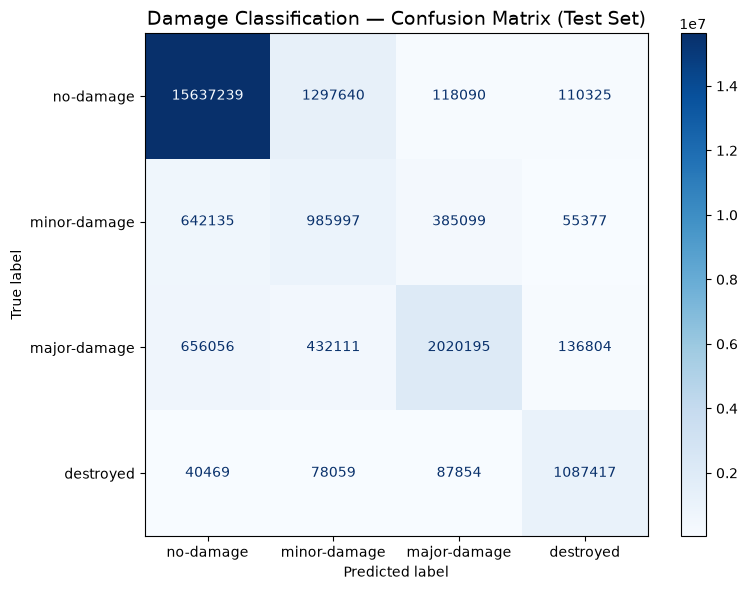

Saved to /teamspace/studios/this_studio/demo_sites/confusion_matrix.png


In [13]:
# Confusion matrix on test set
model.eval()
all_dmg_preds = []
all_dmg_targets = []
all_building_masks = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Building confusion matrix"):
        pre = batch['pre_img'].to(DEVICE)
        post = batch['post_img'].to(DEVICE)
        building_px = batch['building_pixels']
        dmg_target = batch['dmg_mask']
        
        with torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE):
            _, dmg_logits = model(pre, post)
        
        dmg_pred = dmg_logits.argmax(dim=1).cpu()
        all_dmg_preds.append(dmg_pred)
        all_dmg_targets.append(dmg_target)
        all_building_masks.append(building_px)

all_dmg_preds = torch.cat(all_dmg_preds).numpy().flatten()
all_dmg_targets = torch.cat(all_dmg_targets).numpy().flatten()
all_building_masks = torch.cat(all_building_masks).numpy().flatten()

# Filter to building pixels only
mask = all_building_masks.astype(bool)
dmg_preds_masked = all_dmg_preds[mask]
dmg_targets_masked = all_dmg_targets[mask]

tier_names = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']
cm = confusion_matrix(dmg_targets_masked, dmg_preds_masked, labels=[0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Damage Classification — Confusion Matrix (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()
print(f"Saved to {OUTPUT_DIR / 'confusion_matrix.png'}")

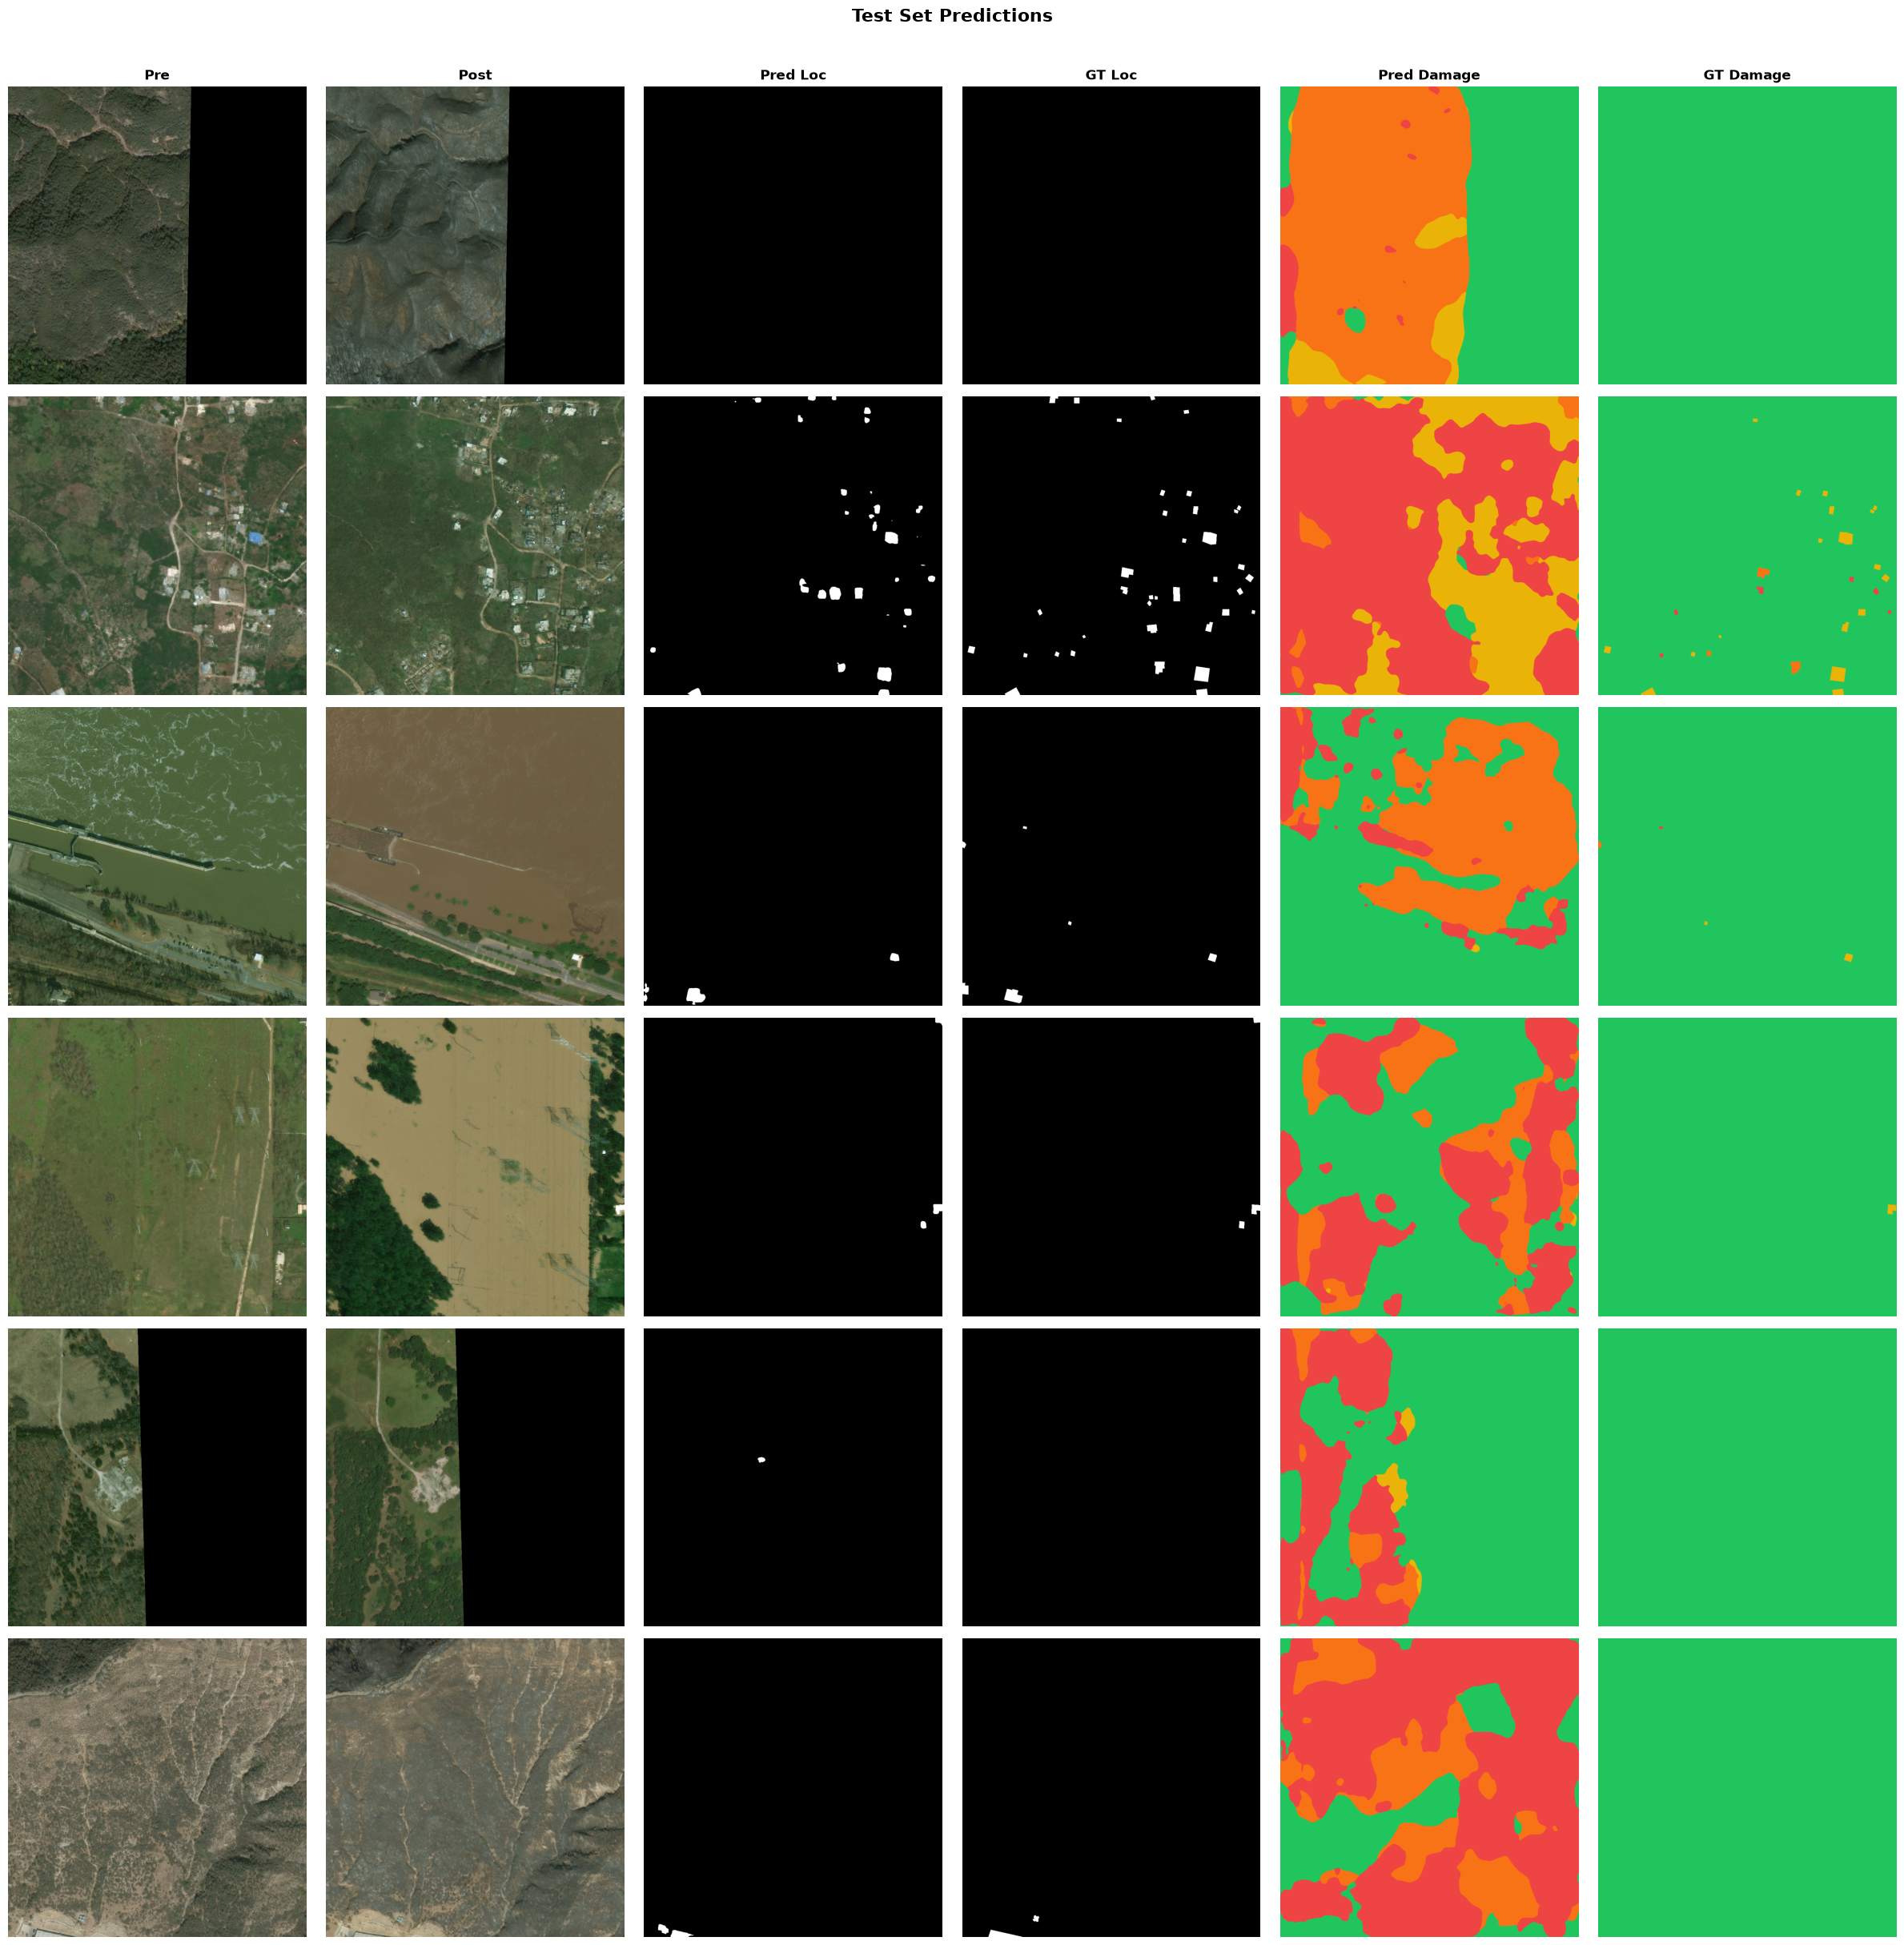

Saved to /teamspace/studios/this_studio/demo_sites/test_predictions.png


In [14]:
# Visualize predictions on 6 test samples
DAMAGE_COLORS = {
    0: [0.133, 0.773, 0.369],   # no-damage:    #22c55e (green)
    1: [0.918, 0.702, 0.031],   # minor-damage:  #eab308 (yellow)
    2: [0.976, 0.451, 0.086],   # major-damage:  #f97316 (orange)
    3: [0.937, 0.267, 0.267],   # destroyed:     #ef4444 (red)
}

def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Undo ImageNet normalization for display."""
    t = tensor.clone()
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]
    return t.clamp(0, 1)

def colorize_damage(mask, num_classes=4):
    """Convert damage class mask to RGB image."""
    h, w = mask.shape
    rgb = np.zeros((h, w, 3))
    for cls, color in DAMAGE_COLORS.items():
        rgb[mask == cls] = color
    return rgb


model.eval()
fig, axes = plt.subplots(6, 6, figsize=(24, 24))
columns = ['Pre', 'Post', 'Pred Loc', 'GT Loc', 'Pred Damage', 'GT Damage']

for col, title in enumerate(columns):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

sample_indices = list(range(min(6, len(test_dataset))))

for row, idx in enumerate(sample_indices):
    sample = test_dataset[idx]
    pre = sample['pre_img'].unsqueeze(0).to(DEVICE)
    post = sample['post_img'].unsqueeze(0).to(DEVICE)
    
    with torch.no_grad(), torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE):
        loc_logits, dmg_logits = model(pre, post)
    
    loc_pred = (torch.sigmoid(loc_logits.squeeze()) > 0.5).cpu().numpy()
    dmg_pred = dmg_logits.argmax(dim=1).squeeze().cpu().numpy()
    
    pre_img = denormalize(sample['pre_img']).permute(1, 2, 0).numpy()
    post_img = denormalize(sample['post_img']).permute(1, 2, 0).numpy()
    loc_gt = sample['loc_mask'].numpy()
    dmg_gt = sample['dmg_mask'].numpy()
    
    axes[row, 0].imshow(pre_img)
    axes[row, 1].imshow(post_img)
    axes[row, 2].imshow(loc_pred, cmap='gray')
    axes[row, 3].imshow(loc_gt, cmap='gray')
    axes[row, 4].imshow(colorize_damage(dmg_pred))
    axes[row, 5].imshow(colorize_damage(dmg_gt))
    
    for col in range(6):
        axes[row, col].axis('off')

plt.suptitle('Test Set Predictions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'test_predictions.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'test_predictions.png'}")

---
## Cell 10 — Export Function

Converts model predictions into the DATA CONTRACT format:
- `pre.png`, `post.png` (RGB images)
- `damage.geojson` (vectorized building polygons with damage tiers)
- Returns a `summary` dict for manifest.json

In [15]:
import json
from shapely.geometry import shape, mapping
from shapely.affinity import affine_transform
import rasterio.features

TIER_MAP = {0: "no-damage", 1: "minor-damage", 2: "major-damage", 3: "destroyed"}


def export_site(model, pre_img_np, post_img_np, site_id, site_name, source,
                center, bounds, output_dir, device=None, amp_dtype=None,
                transform=None, img_size=1024):
    """Run inference on a single pre/post pair and write DATA CONTRACT files.
    
    Args:
        model: trained SiameseDamageNet
        pre_img_np: (H, W, 3) uint8 numpy array — raw pre-disaster image
        post_img_np: (H, W, 3) uint8 numpy array — raw post-disaster image
        site_id: e.g. "site_001"
        site_name: human-readable name
        source: "xbd_test" or "maxar_ood"
        center: {"lat": float, "lng": float}
        bounds: [[south, west], [north, east]]
        output_dir: Path to write files
        device: torch device
        amp_dtype: mixed precision dtype
        transform: albumentations val transform
        img_size: expected input size
    
    Returns:
        summary: dict with counts
    """
    if device is None:
        device = DEVICE
    if amp_dtype is None:
        amp_dtype = AMP_DTYPE
    if transform is None:
        transform = get_augmentation(img_size, is_train=False)
    
    site_dir = Path(output_dir) / site_id
    site_dir.mkdir(parents=True, exist_ok=True)
    
    # Save raw images as PNG
    Image.fromarray(pre_img_np).save(site_dir / "pre.png")
    Image.fromarray(post_img_np).save(site_dir / "post.png")
    
    # Preprocess for model
    transformed = transform(
        image=pre_img_np,
        image_post=post_img_np,
        mask=np.zeros(pre_img_np.shape[:2], dtype=np.uint8),
        mask_dmg=np.zeros(pre_img_np.shape[:2], dtype=np.uint8),
    )
    pre_tensor = transformed['image'].unsqueeze(0).to(device)
    post_tensor = transformed['image_post'].unsqueeze(0).to(device)
    
    # Inference
    model.eval()
    with torch.no_grad(), torch.amp.autocast(device_type=device.type, dtype=amp_dtype):
        loc_logits, dmg_logits = model(pre_tensor, post_tensor)
    
    # Post-process
    loc_mask = (torch.sigmoid(loc_logits.squeeze()) > 0.5).cpu().numpy().astype(np.uint8)
    dmg_pred = dmg_logits.argmax(dim=1).squeeze().cpu().numpy()
    dmg_conf = torch.softmax(dmg_logits, dim=1).max(dim=1).values.squeeze().cpu().numpy()
    
    # Vectorize building footprints to polygons
    h, w = loc_mask.shape
    south, west = bounds[0]
    north, east = bounds[1]
    
    # Pixel to geo coordinate transform
    # pixel (col, row) -> (lng, lat)
    x_scale = (east - west) / w
    y_scale = -(north - south) / h  # negative because row 0 = north
    x_off = west
    y_off = north
    
    # Rasterio transform for shapes()
    from rasterio.transform import from_bounds
    rio_transform = from_bounds(west, south, east, north, w, h)
    
    features = []
    summary = {"total_structures": 0, "no_damage": 0, "minor_damage": 0,
               "major_damage": 0, "destroyed": 0}
    
    # Extract connected building polygons
    for geom, value in rasterio.features.shapes(loc_mask, transform=rio_transform):
        if value == 0:
            continue
        
        poly = shape(geom)
        if poly.area < 1e-10:  # skip tiny artifacts
            continue
        
        building_id = summary["total_structures"]
        summary["total_structures"] += 1
        
        # Determine damage tier: majority vote within this polygon
        # Rasterize the polygon back to get pixel indices
        from rasterio.features import geometry_mask
        poly_mask = ~geometry_mask([geom], out_shape=(h, w), transform=rio_transform)
        
        if poly_mask.sum() > 0:
            damage_vals = dmg_pred[poly_mask]
            conf_vals = dmg_conf[poly_mask]
            # Majority vote
            from scipy import stats
            tier_idx = int(stats.mode(damage_vals, keepdims=False).mode)
            avg_conf = float(conf_vals.mean())
        else:
            tier_idx = 0
            avg_conf = 0.5
        
        tier_name = TIER_MAP[tier_idx]
        
        # Count
        summary_key = tier_name.replace("-", "_")
        summary[summary_key] += 1
        
        features.append({
            "type": "Feature",
            "geometry": mapping(poly),
            "properties": {
                "building_id": building_id,
                "damage_tier": tier_name,
                "confidence": round(avg_conf, 3),
            }
        })
    
    # Write GeoJSON
    geojson = {
        "type": "FeatureCollection",
        "features": features,
    }
    with open(site_dir / "damage.geojson", "w") as f:
        json.dump(geojson, f, indent=2)
    
    print(f"  📍 {site_id} ({site_name}): {summary['total_structures']} structures exported")
    print(f"     Tiers: ND={summary['no_damage']}, Mi={summary['minor_damage']}, "
          f"Ma={summary['major_damage']}, De={summary['destroyed']}")
    
    return summary

print("✅ export_site() defined.")

✅ export_site() defined.


---
## Cell 11 — Generate Demo Sites from xBD Test Split
Pick 3-4 diverse test images and export them in DATA CONTRACT format.

In [16]:
# Select diverse test samples (different disaster types)
demo_configs = []
seen_disasters = set()

for i in range(len(test_hf)):
    name = test_hf[i]['image_name']
    dtype = extract_disaster_type(name)
    if dtype not in seen_disasters:
        seen_disasters.add(dtype)
        demo_configs.append({
            'idx': i,
            'disaster_type': dtype,
            'image_name': name,
        })
    if len(demo_configs) >= 4:
        break

print(f"Selected {len(demo_configs)} demo sites:")
for dc in demo_configs:
    print(f"  idx={dc['idx']}, type={dc['disaster_type']}, name={dc['image_name']}")

# Generate demo site data
manifest_sites = []
val_transform = get_augmentation(IMG_SIZE, is_train=False)

for site_num, dc in enumerate(demo_configs, start=1):
    row = test_hf[dc['idx']]
    
    # Decode raw images
    pre_data = row['t1_image']
    post_data = row['t2_image']
    
    if isinstance(pre_data, Image.Image):
        pre_np = np.array(pre_data.convert('RGB'))
    elif isinstance(pre_data, dict) and 'bytes' in pre_data:
        pre_np = np.array(Image.open(io.BytesIO(pre_data['bytes'])).convert('RGB'))
    else:
        pre_np = np.array(Image.open(io.BytesIO(pre_data)).convert('RGB'))
    
    if isinstance(post_data, Image.Image):
        post_np = np.array(post_data.convert('RGB'))
    elif isinstance(post_data, dict) and 'bytes' in post_data:
        post_np = np.array(Image.open(io.BytesIO(post_data['bytes'])).convert('RGB'))
    else:
        post_np = np.array(Image.open(io.BytesIO(post_data)).convert('RGB'))
    
    site_id = f"site_{site_num:03d}"
    site_name = dc['disaster_type'].replace('-', ' ').title()
    
    # Real approximate location of each disaster event -- this dataset's
    # columns (t1_image/t2_image/t1_mask/t2_mask/image_name) don't include
    # per-tile geolocation, but the DISASTER TYPE is known from image_name,
    # and each xBD event happened at one well-known real place. An earlier
    # version of this cell used a fabricated formula (base_lat = 30.0 +
    # site_num * 2.5) that put demo sites at made-up coordinates unrelated
    # to where the imagery was actually taken -- fine mechanically, but a
    # real problem for a presentation: the map would show, say, rural
    # Alabama under a tile that's actually the Palu, Indonesia tsunami.
    # This is a per-EVENT approximate centroid, not per-tile precision --
    # good enough to be truthful about "this happened near here," which is
    # what actually matters for a demo audience.
    DISASTER_LOCATIONS = {
        "hurricane-michael":    {"lat": 29.95,  "lng": -85.41},   # Mexico Beach, FL
        "hurricane-harvey":     {"lat": 29.76,  "lng": -95.37},   # Houston, TX
        "hurricane-florence":   {"lat": 34.22,  "lng": -77.94},   # Wilmington, NC
        "hurricane-matthew":    {"lat": 18.64,  "lng": -74.11},   # Jeremie, Haiti
        "midwest-flooding":     {"lat": 41.50,  "lng": -96.00},   # Nebraska, USA
        "santa-rosa-wildfire":  {"lat": 38.44,  "lng": -122.71},  # Santa Rosa, CA
        "mexico-earthquake":    {"lat": 18.40,  "lng": -98.85},   # Puebla, Mexico
        "palu-tsunami":         {"lat": -0.90,  "lng": 119.85},   # Palu, Indonesia
        "socal-fire":           {"lat": 34.28,  "lng": -119.29},  # Ventura, CA
        "guatemala-volcano":    {"lat": 14.47,  "lng": -90.88},   # Fuego volcano, Guatemala
    }
    if dc['disaster_type'] in DISASTER_LOCATIONS:
        center = DISASTER_LOCATIONS[dc['disaster_type']]
    else:
        # Fallback for any disaster type not in the lookup above -- keeps
        # the notebook from crashing on an unexpected type, but flags it
        # clearly rather than silently using a fake location.
        print(f"  ⚠️  No known real location for '{dc['disaster_type']}' -- "
              f"using a placeholder center. Add it to DISASTER_LOCATIONS above.")
        center = {"lat": 0.0, "lng": 0.0}
    half_deg = 0.005  # ~500m at equator -- xBD tiles are roughly this size
    bounds = [
        [center["lat"] - half_deg, center["lng"] - half_deg],
        [center["lat"] + half_deg, center["lng"] + half_deg],
    ]
    
    summary = export_site(
        model, pre_np, post_np,
        site_id=site_id,
        site_name=site_name,
        source="xbd_test",
        center=center,
        bounds=bounds,
        output_dir=OUTPUT_DIR,
        device=DEVICE,
        amp_dtype=AMP_DTYPE,
        transform=val_transform,
        img_size=IMG_SIZE,
    )
    
    manifest_sites.append({
        "id": site_id,
        "name": site_name,
        "source": "xbd_test",
        "center": center,
        "bounds": bounds,
        "pre_image": f"/data/{site_id}/pre.png",
        "post_image": f"/data/{site_id}/post.png",
        "damage_geojson": f"/data/{site_id}/damage.geojson",
        "summary": summary,
    })

# Write manifest.json
manifest = {"sites": manifest_sites}
manifest_path = OUTPUT_DIR / "manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\n✅ Manifest written to: {manifest_path}")
print(f"\nCopy the following to frontend/public/data/:")
print(f"  - {manifest_path}")
for site in manifest_sites:
    print(f"  - {OUTPUT_DIR / site['id']}/")
print(json.dumps(manifest, indent=2))

Selected 4 demo sites:
  idx=0, type=train/images/socal-fire, name=train/images/socal-fire_00000160
  idx=1, type=train/images/hurricane-matthew, name=train/images/hurricane-matthew_00000347
  idx=2, type=train/images/midwest-flooding, name=train/images/midwest-flooding_00000021
  idx=3, type=train/images/hurricane-harvey, name=train/images/hurricane-harvey_00000196
  ⚠️  No known real location for 'train/images/socal-fire' -- using a placeholder center. Add it to DISASTER_LOCATIONS above.
  📍 site_001 (Train/Images/Socal Fire): 0 structures exported
     Tiers: ND=0, Mi=0, Ma=0, De=0
  ⚠️  No known real location for 'train/images/hurricane-matthew' -- using a placeholder center. Add it to DISASTER_LOCATIONS above.
  📍 site_002 (Train/Images/Hurricane Matthew): 33 structures exported
     Tiers: ND=0, Mi=25, Ma=0, De=8
  ⚠️  No known real location for 'train/images/midwest-flooding' -- using a placeholder center. Add it to DISASTER_LOCATIONS above.
  📍 site_003 (Train/Images/Midwest Fl

---
## Cell 12 — OPTIONAL: Ordinal Loss

**This cell is OPTIONAL and can be skipped.** It adds an ordinal regression loss that
penalizes predictions more heavily when they are farther from the true damage tier.
This is not required for the rest of the notebook to run — it's an experiment to
potentially improve damage classification accuracy.

In [17]:
# ═══════════════════════════════════════════════════════════
# OPTIONAL: Ordinal Loss — skip if time is short
# ═══════════════════════════════════════════════════════════

class OrdinalLoss(nn.Module):
    """Ordinal regression loss for ordered damage tiers.
    
    Converts the 4-class problem into 3 binary thresholds:
      tier >= 1 (minor or worse)
      tier >= 2 (major or worse)  
      tier >= 3 (destroyed)
    
    This encodes the ordinal relationship between tiers.
    """
    def __init__(self, num_classes=4):
        super().__init__()
        self.num_thresholds = num_classes - 1
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, logits, targets):
        """logits: (N, 4), targets: (N,) with values 0-3."""
        # We use the first 3 logit channels as ordinal thresholds
        loss = 0.0
        for k in range(self.num_thresholds):
            binary_target = (targets > k).float()
            loss += self.bce(logits[:, k], binary_target)
        return loss / self.num_thresholds

# To use: add ordinal_loss to the damage loss computation:
# ordinal_criterion = OrdinalLoss()
# ordinal_term = ordinal_criterion(dmg_logits_masked, dmg_targets_masked)
# total_damage_loss = ce_loss + 0.3 * ordinal_term

print("✅ OrdinalLoss defined (optional — not used in default training loop).")

✅ OrdinalLoss defined (optional — not used in default training loop).


---
## Cell 13 — CPU Dry Run (MANDATORY)

Before declaring this notebook complete, verify the FULL pipeline runs without errors
using synthetic data on CPU. This catches shape mismatches, import errors, and logic bugs.

In [ ]:
print("="*60)
print("CPU DRY RUN — Full pipeline on synthetic data")
print("="*60)

import tempfile

# Use a temporary directory for dry run outputs
with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir = Path(tmpdir)
    
    # Step 1: Generate synthetic data
    print("\n[1/7] Generating synthetic data...")
    SYNTH_SIZE = 256  # Small for speed
    synth_samples = []
    for i in range(4):
        pre = np.random.randint(0, 255, (SYNTH_SIZE, SYNTH_SIZE, 3), dtype=np.uint8)
        post = np.random.randint(0, 255, (SYNTH_SIZE, SYNTH_SIZE, 3), dtype=np.uint8)
        loc_mask = np.zeros((SYNTH_SIZE, SYNTH_SIZE), dtype=np.uint8)
        dmg_mask = np.zeros((SYNTH_SIZE, SYNTH_SIZE), dtype=np.uint8)
        # Add some fake buildings
        loc_mask[50:100, 50:100] = 1
        loc_mask[150:200, 150:200] = 1
        dmg_mask[50:100, 50:100] = i + 1    # damage tier 1-4
        dmg_mask[150:200, 150:200] = ((i + 2) % 4) + 1
        synth_samples.append({
            't1_image': Image.fromarray(pre),
            't2_image': Image.fromarray(post),
            't1_mask': Image.fromarray(loc_mask),
            't2_mask': Image.fromarray(dmg_mask),
            'image_name': f'synth-disaster_{i:05d}_pre_disaster.png',
        })
    print(f"  Created {len(synth_samples)} synthetic samples ({SYNTH_SIZE}x{SYNTH_SIZE})")
    
    # Step 2: Create dataset & dataloader
    print("\n[2/7] Building dataset & dataloader...")
    from datasets import Dataset as HFDataset
    synth_hf = HFDataset.from_list(synth_samples)
    synth_transform = get_augmentation(SYNTH_SIZE, is_train=True)
    synth_dataset = XBDDataset(synth_hf, transform=synth_transform, img_size=SYNTH_SIZE)
    synth_loader = DataLoader(synth_dataset, batch_size=2, shuffle=True, num_workers=0)
    
    # Test a batch
    batch = next(iter(synth_loader))
    print(f"  pre_img shape:       {batch['pre_img'].shape}")
    print(f"  post_img shape:      {batch['post_img'].shape}")
    print(f"  loc_mask shape:      {batch['loc_mask'].shape}")
    print(f"  dmg_mask shape:      {batch['dmg_mask'].shape}")
    print(f"  building_pixels shape: {batch['building_pixels'].shape}")
    
    # Step 3: Model forward pass on CPU
    print("\n[3/7] Model forward pass (CPU)...")
    cpu_model = SiameseDamageNet(encoder_name="resnet50", encoder_weights=None)  # No pretrained for speed
    cpu_model.eval()
    with torch.no_grad():
        loc_out, dmg_out = cpu_model(batch['pre_img'], batch['post_img'])
    print(f"  loc_logits shape: {loc_out.shape}")
    print(f"  dmg_logits shape: {dmg_out.shape}")
    assert loc_out.shape == (2, 1, SYNTH_SIZE, SYNTH_SIZE)
    assert dmg_out.shape == (2, 4, SYNTH_SIZE, SYNTH_SIZE)
    
    # Step 4: Loss computation
    print("\n[4/7] Loss computation...")
    cpu_model.train()
    loc_out, dmg_out = cpu_model(batch['pre_img'], batch['post_img'])
    
    cpu_loc_crit = LocalizationLoss(bce_weight=0.5, dice_weight=0.5)
    cpu_dmg_crit = DamageLoss(class_weights=torch.ones(4), use_focal=False)
    
    loss_loc = cpu_loc_crit(loc_out, batch['loc_mask'])
    loss_dmg = cpu_dmg_crit(dmg_out, batch['dmg_mask'], batch['building_pixels'])
    total_loss = loss_loc + loss_dmg
    print(f"  loc_loss: {loss_loc.item():.4f}")
    print(f"  dmg_loss: {loss_dmg.item():.4f}")
    print(f"  total:    {total_loss.item():.4f}")
    
    # Step 5: Optimizer step
    print("\n[5/7] Backward + optimizer step...")
    cpu_optimizer = torch.optim.AdamW(cpu_model.parameters(), lr=1e-4)
    cpu_optimizer.zero_grad()
    total_loss.backward()
    cpu_optimizer.step()
    print("  ✅ Optimizer step completed")
    
    # Step 6: Checkpoint save/load
    print("\n[6/7] Checkpoint save/load...")
    cpu_scaler = torch.amp.GradScaler(device="cpu", enabled=False)
    ckpt_path = save_checkpoint(tmpdir, cpu_model, cpu_optimizer, cpu_scaler, 0, 1, 0.0, tag="_dryrun")
    
    # Reload
    cpu_model2 = SiameseDamageNet(encoder_name="resnet50", encoder_weights=None)
    cpu_optimizer2 = torch.optim.AdamW(cpu_model2.parameters(), lr=1e-4)
    load_checkpoint(ckpt_path, model=cpu_model2, optimizer=cpu_optimizer2)
    
    # Verify weights match
    for (n1, p1), (n2, p2) in zip(cpu_model.named_parameters(), cpu_model2.named_parameters()):
        assert torch.equal(p1, p2), f"Parameter mismatch: {n1}"
    print("  ✅ Checkpoint roundtrip verified")
    
    # Step 7: Export function
    print("\n[7/7] Export function (export_site)...")
    synth_pre = np.random.randint(0, 255, (SYNTH_SIZE, SYNTH_SIZE, 3), dtype=np.uint8)
    synth_post = np.random.randint(0, 255, (SYNTH_SIZE, SYNTH_SIZE, 3), dtype=np.uint8)
    
    export_transform = get_augmentation(SYNTH_SIZE, is_train=False)
    summary = export_site(
        cpu_model,
        synth_pre, synth_post,
        site_id="site_dryrun",
        site_name="Dry Run Test",
        source="xbd_test",
        center={"lat": 0.0, "lng": 0.0},
        bounds=[[-0.005, -0.005], [0.005, 0.005]],
        output_dir=tmpdir / "export",
        device=torch.device("cpu"),
        amp_dtype=torch.float32,
        transform=export_transform,
        img_size=SYNTH_SIZE,
    )
    
    # Verify files exist
    export_dir = tmpdir / "export" / "site_dryrun"
    assert (export_dir / "pre.png").exists(), "pre.png not created"
    assert (export_dir / "post.png").exists(), "post.png not created"
    assert (export_dir / "damage.geojson").exists(), "damage.geojson not created"
    
    # Verify GeoJSON structure
    with open(export_dir / "damage.geojson") as f:
        geojson = json.load(f)
    assert geojson['type'] == 'FeatureCollection'
    print(f"  GeoJSON: {len(geojson['features'])} features")
    print(f"  Summary: {summary}")
    
    # Cleanup
    del cpu_model, cpu_model2, cpu_optimizer, cpu_optimizer2

print("\n" + "="*60)
print("✅ CPU DRY RUN PASSED — All 7 steps completed without errors")
print("="*60)

CPU DRY RUN — Full pipeline on synthetic data

[1/7] Generating synthetic data...
  Created 4 synthetic samples (256x256)

[2/7] Building dataset & dataloader...
  pre_img shape:       torch.Size([2, 3, 256, 256])
  post_img shape:      torch.Size([2, 3, 256, 256])
  loc_mask shape:      torch.Size([2, 256, 256])
  dmg_mask shape:      torch.Size([2, 256, 256])
  building_pixels shape: torch.Size([2, 256, 256])

[3/7] Model forward pass (CPU)...
  loc_logits shape: torch.Size([2, 1, 256, 256])
  dmg_logits shape: torch.Size([2, 4, 256, 256])

[4/7] Loss computation...
  loc_loss: 0.7175
  dmg_loss: 1.6334
  total:    2.3509

[5/7] Backward + optimizer step...
  ✅ Optimizer step completed

[6/7] Checkpoint save/load...
  💾 Checkpoint saved: checkpoint_epoch000_step000001_dryrun.pt


---
## Cells 14-18 — OPTIONAL: Real-World OOD Demo Sites (Maxar Open Data)

⚠️ **This entire section is OPTIONAL.** Skip if:
- Time/GPU budget is running short
- Network issues prevent downloading Maxar imagery
- Pre/post coverage gaps exist for the target AOIs

The xBD test sites from Cell 11 already guarantee a working demo.

In [ ]:
# Cell 14 — Maxar Open Data Setup
# ═══════════════════════════════════════════════════════════
# OPTIONAL — Install additional deps for Maxar data access
# ═══════════════════════════════════════════════════════════

try:
    pip_install("pystac-client>=0.7", "leafmap>=0.35", "rio-tiler>=6.0")
    import pystac_client
    print("✅ Maxar OOD dependencies installed.")
except Exception as e:
    print(f"⚠️  Could not install Maxar deps: {e}")
    print("   Skipping OOD section.")

In [ ]:
# Cell 15 — Event AOI Selection
# ═══════════════════════════════════════════════════════════
# Access Maxar Open Data STAC catalog and select AOIs
# ═══════════════════════════════════════════════════════════

import requests

# Each event below now has MULTIPLE aoi_centers, not just one -- all
# independently verified against the actual Maxar Open Data footprint
# GeoJSONs (opengeos/maxar-open-data): for each, confirmed there's a real
# quadkey tile with both a genuine pre-event AND genuine post-event
# acquisition nearby (not just two post-event dates a day apart, and not
# a point with zero coverage at all -- both of those happened with the
# original single hardcoded point per event). Picked to be geographically
# spread out within each event (not adjacent tiles of the same spot), so
# multiple sites per event actually show different areas.
MAXAR_EVENTS = [
    {
        "event_id": "Nepal-Earthquake-Nov-2023",
        "name": "Jajarkot Earthquake, Nepal",
        "aoi_radius_deg": 0.02,
        "aoi_centers": [
            {"lat": 28.8842, "lng": 82.1590},  # verified: 2014-12-04 (pre) + 2023-11-09 (post)
            {"lat": 28.8839, "lng": 82.2051},  # verified: 2014-12-04 (pre) + 2023-11-09 (post)
            {"lat": 28.8181, "lng": 82.1589},  # verified: 2014-12-04 (pre) + 2023-11-09 (post)
            {"lat": 28.8179, "lng": 82.2041},  # verified: 2014-12-04 (pre) + 2023-11-09 (post)
        ],
    },
    {
        "event_id": "Nepal-Floods-Sept-2024",
        "name": "Nepal Floods 2024",
        "aoi_radius_deg": 0.015,
        "aoi_centers": [
            {"lat": 27.7645, "lng": 85.4089},  # verified: 2022-11-22 (pre) + 2024-10-06 (post)
            {"lat": 27.7649, "lng": 85.4524},  # verified: 2022-11-22 (pre) + 2024-10-06 (post)
            {"lat": 27.7226, "lng": 85.4090},  # verified: 2022-11-22 (pre) + 2024-10-06 (post)
            {"lat": 27.7232, "lng": 85.4530},  # verified: 2022-11-22 (pre) + 2024-10-06 (post)
        ],
    },
    {
        "event_id": "India-Floods-Oct-2023",
        "name": "Sikkim GLOF Floods, India",
        "aoi_radius_deg": 0.02,
        "aoi_centers": [
            {"lat": 27.9368, "lng": 88.1104},  # verified: 2023-02-07 (pre) + 2023-10-06 (post)
            {"lat": 27.9367, "lng": 88.1816},  # verified: 2023-02-07 (pre) + 2023-10-06 (post)
            {"lat": 27.8710, "lng": 88.1113},  # verified: 2023-02-07 (pre) + 2023-10-06 (post)
            {"lat": 27.9077, "lng": 88.1432},  # verified: 2023-02-07 (pre) + 2023-10-06 (post)
        ],
    },
]

# Try to load footprint GeoJSON from opengeos/maxar-open-data
OPENGEOS_BASE = "https://github.com/opengeos/maxar-open-data/raw/master/datasets"

for event in MAXAR_EVENTS:
    url = f"{OPENGEOS_BASE}/{event['event_id']}.geojson"
    print(f"\n📡 Fetching footprint: {event['event_id']}")
    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code == 200:
            footprint = resp.json()
            n_features = len(footprint.get('features', []))
            print(f"  ✅ {n_features} image tiles available")
            event['footprint'] = footprint
        else:
            print(f"  ⚠️  HTTP {resp.status_code} — skipping this event")
            event['footprint'] = None
    except Exception as e:
        print(f"  ⚠️  Error: {e} — skipping")
        event['footprint'] = None

available_events = [e for e in MAXAR_EVENTS if e.get('footprint')]
total_candidate_sites = sum(len(e['aoi_centers']) for e in available_events)
print(f"\n{len(available_events)}/{len(MAXAR_EVENTS)} events have available footprints "
      f"({total_candidate_sites} candidate sites total -- some may still be skipped "
      f"individually in Cell 17 if a specific tile pair fails).")

In [ ]:
# Cell 16 — Download & Co-register
# ═══════════════════════════════════════════════════════════
# Download pre/post COG tiles for each AOI, co-register, and crop
# ═══════════════════════════════════════════════════════════

from datetime import datetime

def find_pre_post_tiles(footprint_geojson, aoi_center, aoi_radius):
    """From a footprint GeoJSON, find the best pre and post tiles for an AOI."""
    if not footprint_geojson or 'features' not in footprint_geojson:
        return None, None
    
    aoi_bbox = [
        aoi_center['lng'] - aoi_radius,
        aoi_center['lat'] - aoi_radius,
        aoi_center['lng'] + aoi_radius,
        aoi_center['lat'] + aoi_radius,
    ]
    
    # Filter features that overlap our AOI
    from shapely.geometry import box, shape as shapely_shape
    aoi_poly = box(*aoi_bbox)
    
    candidates = []
    for feature in footprint_geojson['features']:
        try:
            geom = shapely_shape(feature['geometry'])
            if geom.intersects(aoi_poly):
                props = feature.get('properties', {})
                candidates.append({
                    'feature': feature,
                    'geometry': geom,
                    'properties': props,
                })
        except Exception:
            continue
    
    if len(candidates) < 2:
        print(f"  Only {len(candidates)} tiles overlap AOI — need at least 2")
        return None, None
    
    # Sort by acquisition date if available
    for c in candidates:
        date_str = c['properties'].get('datetime', c['properties'].get('acquisition_date', ''))
        try:
            c['date'] = datetime.fromisoformat(date_str.replace('Z', '+00:00'))
        except Exception:
            c['date'] = None
    
    dated = [c for c in candidates if c['date'] is not None]
    if len(dated) >= 2:
        dated.sort(key=lambda x: x['date'])
        return dated[0], dated[-1]  # earliest = pre, latest = post
    
    # Fallback: just use first two
    return candidates[0], candidates[1]


def download_and_crop_cog(tile_url, aoi_bbox, output_path, target_size=1024):
    """Download a windowed read from a COG and crop to AOI.

    `aoi_bbox` is (minlng, minlat, maxlng, maxlat) in EPSG:4326 (plain
    lat/lng degrees).
    """
    import rasterio
    from rasterio.windows import from_bounds
    from rasterio.warp import transform_bounds, calculate_default_transform, reproject, Resampling
    
    try:
        with rasterio.open(tile_url) as src:
            # CRITICAL: Maxar ARD COG tiles are stored in a local UTM CRS
            # (confirmed against real tile metadata -- e.g. proj:epsg 32642,
            # 32612, 32760, etc, with proj:bbox values in the hundreds-of-
            # thousands, i.e. meters, not degrees), never plain EPSG:4326.
            # aoi_bbox is in lat/lng degrees. Passing degree-scale numbers
            # straight into from_bounds() against a meters-scale transform
            # computes a pixel window wildly outside the actual image (e.g.
            # asking for column -1,099,835), and rasterio/GDAL pads the
            # result with nodata (0) rather than erroring -- so this failed
            # silently as a fully black image, not a crash. Reproject the
            # AOI into the raster's own CRS first.
            if src.crs is not None and src.crs.to_epsg() != 4326:
                aoi_bbox_native = transform_bounds("EPSG:4326", src.crs, *aoi_bbox)
            else:
                aoi_bbox_native = aoi_bbox
            window = from_bounds(*aoi_bbox_native, transform=src.transform)
            data = src.read(window=window)
            if data.size == 0 or data.max() == 0:
                print(f"  ⚠️  Window read returned empty/all-zero data for {tile_url[:60]}... "
                      f"(AOI likely doesn't overlap this specific tile's actual coverage)")
                return None
            
            if data.shape[0] >= 3:
                rgb = data[:3]  # Take first 3 bands
            else:
                rgb = np.stack([data[0]] * 3)  # Grayscale to RGB
            
            # Resize to target
            from PIL import Image as PILImage
            # Normalize to 0-255
            rgb_norm = np.moveaxis(rgb, 0, -1)  # (H, W, 3)
            if rgb_norm.dtype != np.uint8:
                # Scale to 0-255
                vmin, vmax = np.percentile(rgb_norm, [2, 98])
                rgb_norm = np.clip((rgb_norm - vmin) / (vmax - vmin + 1e-8) * 255, 0, 255).astype(np.uint8)
            
            img = PILImage.fromarray(rgb_norm).resize((target_size, target_size), PILImage.LANCZOS)
            img.save(output_path)
            return np.array(img)
    except Exception as e:
        print(f"  ⚠️  Error downloading COG: {e}")
        return None

print("Download/co-register functions defined.")
print("Note: Actual download depends on Maxar COG URLs being accessible.")

In [ ]:
# Cell 17 — Run Inference on OOD Sites
# ═══════════════════════════════════════════════════════════

ood_sites = []

for event in available_events:
    for sub_idx, aoi_center in enumerate(event['aoi_centers']):
        sub_label = f"{event['name']} (Area {sub_idx + 1})" if len(event['aoi_centers']) > 1 else event['name']
        print(f"\n{'─'*50}")
        print(f"Processing: {sub_label}")

        aoi_radius = event['aoi_radius_deg']

        pre_tile, post_tile = find_pre_post_tiles(
            event['footprint'], aoi_center, aoi_radius
        )

        if pre_tile is None or post_tile is None:
            print(f"  ⚠️  Could not find pre/post tile pair — SKIPPING")
            continue
    
        # Try to extract COG URL from tile properties
        pre_url = pre_tile['properties'].get('visual', pre_tile['properties'].get('href', None))
        post_url = post_tile['properties'].get('visual', post_tile['properties'].get('href', None))

        if not pre_url or not post_url:
            print(f"  ⚠️  No COG URLs found in tile properties — SKIPPING")
            print(f"  Available properties: {list(pre_tile['properties'].keys())}")
            continue

        print(f"  Pre-event tile: {pre_url[:80]}...")
        print(f"  Post-event tile: {post_url[:80]}...")

        aoi_bbox = [
            aoi_center['lng'] - aoi_radius,
            aoi_center['lat'] - aoi_radius,
            aoi_center['lng'] + aoi_radius,
            aoi_center['lat'] + aoi_radius,
        ]

        site_num = len(manifest_sites) + len(ood_sites) + 1
        site_id = f"site_{site_num:03d}"

        pre_path = OUTPUT_DIR / site_id / "pre.png"
        post_path = OUTPUT_DIR / site_id / "post.png"
        (OUTPUT_DIR / site_id).mkdir(parents=True, exist_ok=True)

        pre_np = download_and_crop_cog(pre_url, aoi_bbox, pre_path, target_size=IMG_SIZE)
        post_np = download_and_crop_cog(post_url, aoi_bbox, post_path, target_size=IMG_SIZE)

        if pre_np is None or post_np is None:
            print(f"  ⚠️  Failed to download imagery — SKIPPING")
            continue

        # Run inference
        bounds = [
            [aoi_center['lat'] - aoi_radius, aoi_center['lng'] - aoi_radius],
            [aoi_center['lat'] + aoi_radius, aoi_center['lng'] + aoi_radius],
        ]

        try:
            summary = export_site(
                model, pre_np, post_np,
                site_id=site_id,
                site_name=sub_label,
                source="maxar_ood",
                center=aoi_center,
                bounds=bounds,
                output_dir=OUTPUT_DIR,
                device=DEVICE,
                amp_dtype=AMP_DTYPE,
            )

            ood_sites.append({
                "id": site_id,
                "name": sub_label,
                "source": "maxar_ood",
                "center": aoi_center,
                "bounds": bounds,
                "pre_image": f"/data/{site_id}/pre.png",
                "post_image": f"/data/{site_id}/post.png",
                "damage_geojson": f"/data/{site_id}/damage.geojson",
                "summary": summary,
            })
            print(f"  ✅ Successfully exported {site_id}")
        except Exception as e:
            print(f"  ⚠️  Export failed: {e} — SKIPPING")

print(f"\n✅ {len(ood_sites)} OOD sites processed successfully.")

In [ ]:
# Cell 18 — Update Manifest with OOD Sites
# ═══════════════════════════════════════════════════════════

if ood_sites:
    # Reload existing manifest
    with open(manifest_path) as f:
        manifest = json.load(f)
    
    # Append OOD sites
    manifest['sites'].extend(ood_sites)
    
    # Write updated manifest
    with open(manifest_path, 'w') as f:
        json.dump(manifest, f, indent=2)
    
    print(f"✅ Updated manifest with {len(ood_sites)} OOD sites.")
    print(f"   Total sites: {len(manifest['sites'])}")
else:
    print("No OOD sites to add. Manifest unchanged.")

print(f"\n📁 Final manifest: {manifest_path}")
print(f"\nAll output files are in: {OUTPUT_DIR}")
print("Copy these to frontend/public/data/ to display in the web app.")